Construction des bains HEOM...
Preparing block matrices for HEOM Liouvillian superoperator (using 1 threads)...
Progress: [==============================] 100.0% --- Elapsed Time: 0h 00m 02s (ETA: 0h 00m 00s)
Constructing matrix...[DONE]
Preparing block matrices for HEOM Liouvillian superoperator (using 1 threads)...
Progress: [==============================] 100.0% --- Elapsed Time: 0h 00m 00s (ETA: 0h 00m 00s)
Constructing matrix...[DONE]
Preparing block matrices for HEOM Liouvillian superoperator (using 1 threads)...
Progress: [==============================] 100.0% --- Elapsed Time: 0h 00m 00s (ETA: 0h 00m 00s)
Constructing matrix...[DONE]
Preparing block matrices for HEOM Liouvillian superoperator (using 1 threads)...
Progress: [==============================] 100.0% --- Elapsed Time: 0h 00m 03s (ETA: 0h 00m 00s)
Constructing matrix...[DONE]
Preparing block matrices for HEOM Liouvillian superoperator (using 1 threads)...
Progress: [==============================] 100.0% --- Elapse

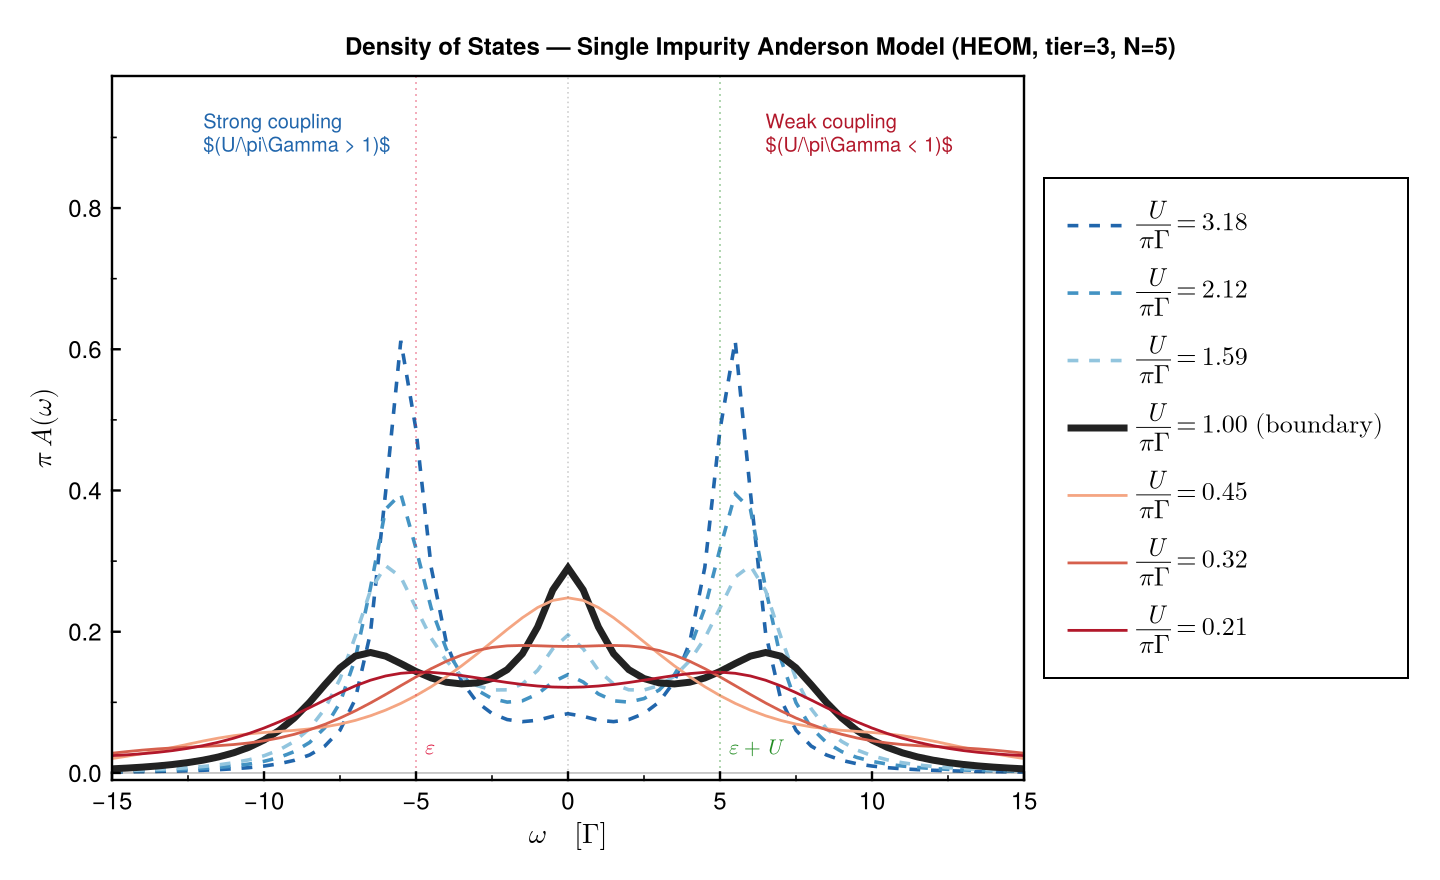

CairoMakie.Screen{IMAGE}


In [2]:
"""
Densité d'états A(ω) via HEOM — Modèle d'Anderson à une impureté
Style publication :
  • Fort couplage  (Γ < Γ*)  : traits interrompus  (---)  couleurs froides
  • Frontière      (Γ = Γ*)  : trait plein épais    (━)   noir/gris foncé
  • Faible couplage(Γ > Γ*)  : traits fins pleins   (──)  couleurs chaudes
"""

using HierarchicalEOM
using CairoMakie, Printf, LaTeXStrings

# ── Système ───────────────────────────────────────────────────────────────────
ϵ  = -5.0
U  = 10.0
σm = sigmam()
σz = sigmaz()
II = qeye(2)

d_up = tensor(σm, II)
d_dn = tensor(-1 * σz, σm)
Hsys = ϵ * (d_up' * d_up + d_dn' * d_dn) + U * (d_up' * d_up * d_dn' * d_dn)

# ── Paramètres des bains ──────────────────────────────────────────────────────
μ    = 0.0
W    = 10.0
kT   = 0.5
N    = 5
tier = 3

# 7 valeurs de Γ couvrant les deux régimes + la frontière exacte
Γ_list = [1.0, 1.5, 2.0, 3.18, 7.0, 10.0, 15.0]
Γ_star = U / π   # ≈ 3.18 — frontière Kondo / métal

# ── Style visuel par régime ───────────────────────────────────────────────────
# Fort couplage  (U/πΓ > 1) : tirets,  couleurs froides (bleu/violet)
# Frontière      (U/πΓ ≈ 1) : plein épais, gris foncé
# Faible couplage(U/πΓ < 1) : plein fin,  couleurs chaudes (orange/rouge)

function regime_style(Γ, Γ_star)
    ratio = U / (π * Γ)
    if abs(ratio - 1.0) < 0.02          # frontière
        return :solid, 3.5, colorant"#222222"
    elseif ratio > 1.0                  # fort couplage (Kondo)
        return :dash, 1.8, nothing
    else                                # faible couplage (métal)
        return :solid, 1.4, nothing
    end
end

# Palettes dédiées (daltonien-friendly)
# Fort couplage  : 3 valeurs → bleus/violets foncés
kondo_colors = [
    colorant"#2166AC",   # bleu roi        (Γ=1.0)
    colorant"#4393C3",   # bleu moyen      (Γ=1.5)
    colorant"#92C5DE",   # bleu clair      (Γ=2.0)
]
# Faible couplage : 3 valeurs → oranges/rouges
metal_colors = [
    colorant"#F4A582",   # saumon          (Γ=7.0)
    colorant"#D6604D",   # rouge-orangé    (Γ=10.0)
    colorant"#B2182B",   # rouge foncé     (Γ=15.0)
]

function get_color(Γ, Γ_star)
    ratio = U / (π * Γ)
    if abs(ratio - 1.0) < 0.02
        return colorant"#222222"
    elseif ratio > 1.0
        idx = findfirst(g -> isapprox(g, Γ; atol=0.05), [1.0, 1.5, 2.0])
        return isnothing(idx) ? colorant"#2166AC" : kondo_colors[idx]
    else
        idx = findfirst(g -> isapprox(g, Γ; atol=0.05), [7.0, 10.0, 15.0])
        return isnothing(idx) ? colorant"#B2182B" : metal_colors[idx]
    end
end

# ── Construction des bains et opérateurs HEOM ─────────────────────────────────
println("Construction des bains HEOM...")
bath_lists   = Vector{Vector}(undef, length(Γ_list))
for (i, γ) in pairs(Γ_list)
    bath_lists[i] = [
        Fermion_Lorentz_Pade(d_up, γ, μ, W, kT, N),
        Fermion_Lorentz_Pade(d_dn, γ, μ, W, kT, N),
    ]
end

M_even_list = [M_Fermion(Hsys, tier, b)       for b in bath_lists]
M_odd_list  = [M_Fermion(Hsys, tier, b, ODD)  for b in bath_lists]

println("Calcul des états stationnaires...")
ados_s_list = [steadystate(M) for M in M_even_list]

# ── Grille de fréquences ──────────────────────────────────────────────────────
ωlist = collect(-15.0:0.5:15.0)

# ── Figure publication ────────────────────────────────────────────────────────
fig = Figure(
    size            = (720, 440),
    backgroundcolor = :white,
)

ax = Axis(fig[1, 1];
    xlabel          = L"\omega \quad [\Gamma]",
    ylabel          = L"\pi \, A(\omega)",
    xlabelsize      = 14,
    ylabelsize      = 14,
    xticklabelsize  = 12,
    yticklabelsize  = 12,
    xtickwidth      = 1.2,
    ytickwidth      = 1.2,
    spinewidth      = 1.2,
    xtickalign      = 1,
    ytickalign      = 1,
    xminorticksvisible = true,
    yminorticksvisible = true,
    xminortickwidth  = 0.8,
    yminortickwidth  = 0.8,
    xminortickalign  = 1,
    yminortickalign  = 1,
    xgridvisible    = false,
    ygridvisible    = false,
    xticks          = LinearTicks(7),
    yticks          = LinearTicks(5),
)

# ── Tracé des courbes ─────────────────────────────────────────────────────────
println("Calcul et tracé des DOS...")

for (i, (M_odd, ados_s, Γ)) in enumerate(zip(M_odd_list, ados_s_list, Γ_list))
    dos = DensityOfStates(M_odd, ados_s, d_up, ωlist)

    ls, lw, _ = regime_style(Γ, Γ_star)
    col        = get_color(Γ, Γ_star)
    ratio_str  = @sprintf("%.2f", U / (π * Γ))

    lines!(ax, ωlist, dos;
        color     = col,
        linewidth = lw,
        linestyle = ls,
        label     = L"U/\pi\Gamma = " * ratio_str,
    )
end

# ── Lignes de référence physiques ─────────────────────────────────────────────
# Niveaux de Hubbard : ε et ε+U
vlines!(ax, [ϵ];
    color     = (:crimson, 0.35),
    linewidth = 1.0,
    linestyle = :dot,
)
vlines!(ax, [ϵ + U];
    color     = (:forestgreen, 0.35),
    linewidth = 1.0,
    linestyle = :dot,
)
# Niveau de Fermi
vlines!(ax, [μ];
    color     = (:black, 0.20),
    linewidth = 0.8,
    linestyle = :dot,
)
hlines!(ax, [0.0];
    color     = (:black, 0.30),
    linewidth = 0.7,
)

# ── Annotations des bandes de Hubbard ────────────────────────────────────────
text!(ax, ϵ + 0.3, 0.02;
    text     = L"\varepsilon",
    fontsize = 11,
    color    = :crimson,
    align    = (:left, :bottom),
)
text!(ax, ϵ + U + 0.3, 0.02;
    text     = L"\varepsilon + U",
    fontsize = 11,
    color    = RGBf(0.13, 0.55, 0.13),
    align    = (:left, :bottom),
)

# ── Annotations de régime en haut du graphe ───────────────────────────────────
text!(ax, -12.0, 0.94;
    text      = "Strong coupling\n" * L"(U/\pi\Gamma > 1)",
    fontsize  = 10,
    color     = colorant"#2166AC",
    align     = (:left, :top),
    space     = :data,
)
text!(ax, 6.5, 0.94;
    text      = "Weak coupling\n" * L"(U/\pi\Gamma < 1)",
    fontsize  = 10,
    color     = colorant"#B2182B",
    align     = (:left, :top),
    space     = :data,
)

# ── Légende personnalisée (haut droite) ───────────────────────────────────────
# Séparation visuelle par régime dans la légende
using Makie: LineElement, MarkerElement

kondo_elems = [
    LineElement(color=kondo_colors[1], linewidth=1.8, linestyle=:dash),
    LineElement(color=kondo_colors[2], linewidth=1.8, linestyle=:dash),
    LineElement(color=kondo_colors[3], linewidth=1.8, linestyle=:dash),
]
# ── Labels LaTeX via latexstring() — seule méthode qui accepte
#    l'interpolation dynamique ET rend du vrai LaTeX dans la légende
r_10  = @sprintf("%.2f", U/(π*1.0))
r_15  = @sprintf("%.2f", U/(π*1.5))
r_20  = @sprintf("%.2f", U/(π*2.0))
r_318 = @sprintf("%.2f", U/(π*3.18))
r_70  = @sprintf("%.2f", U/(π*7.0))
r_100 = @sprintf("%.2f", U/(π*10.0))
r_150 = @sprintf("%.2f", U/(π*15.0))

kondo_labels = [
    latexstring("\\frac{U}{\\pi\\Gamma} = $(r_10)"),
    latexstring("\\frac{U}{\\pi\\Gamma} = $(r_15)"),
    latexstring("\\frac{U}{\\pi\\Gamma} = $(r_20)"),
]

boundary_elem  = [LineElement(color=colorant"#222222", linewidth=3.5, linestyle=:solid)]
boundary_label = [latexstring("\\frac{U}{\\pi\\Gamma} = $(r_318) \\;\\text{(boundary)}")]

metal_elems = [
    LineElement(color=metal_colors[1], linewidth=1.4, linestyle=:solid),
    LineElement(color=metal_colors[2], linewidth=1.4, linestyle=:solid),
    LineElement(color=metal_colors[3], linewidth=1.4, linestyle=:solid),
]
metal_labels = [
    latexstring("\\frac{U}{\\pi\\Gamma} = $(r_70)"),
    latexstring("\\frac{U}{\\pi\\Gamma} = $(r_100)"),
    latexstring("\\frac{U}{\\pi\\Gamma} = $(r_150)"),
]

Legend(fig[1, 2],
    [kondo_elems..., boundary_elem..., metal_elems...],
    [kondo_labels..., boundary_label..., metal_labels...];
    framevisible  = true,
    framewidth    = 1.0,
    labelsize     = 13,
    rowgap        = 6,
    padding       = (12, 12, 10, 10),
    gridshalign   = :left,
    patchsize     = (30, 14),
    title         = latexstring("\\varepsilon=$(Int(ϵ)),\\; U=$(Int(U)),\\; kT=$(kT)"),
    titlesize     = 11,
    titlefont     = :bold,
)

# Largeur de la colonne de légende fixée
colsize!(fig.layout, 2, Auto(0.45))

xlims!(ax, ωlist[1], ωlist[end])
ylims!(ax, -0.01, nothing)

# ── Titre global ──────────────────────────────────────────────────────────────
Label(fig[0, 1:2];
    text      = "Density of States — Single Impurity Anderson Model (HEOM, tier=$tier, N=$N)",
    fontsize  = 12,
    font      = :bold,
    tellwidth = false,
)
rowsize!(fig.layout, 0, Auto(0.08))
rowgap!(fig.layout, 8)
colgap!(fig.layout, 10)

# ── Sauvegarde ────────────────────────────────────────────────────────────────
save("dos_SIAM.pdf", fig)
save("dos_SIAM.png", fig; px_per_unit = 3)

println("\n✓  Figures sauvegardées : dos_SIAM.pdf  /  dos_SIAM.png")
display(fig)